In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding,LSTM #3 (layersa)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
data=pd.read_csv("/content/Movie.zip")

In [ ]:
data.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
data.replace({"sentiment":{"positive":1,"negative":0}},inplace=True)

/tmp/ipykernel_633/3877186056.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"sentiment":{"positive":1,"negative":0}},inplace=True)


In [ ]:
data.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [ ]:
data.duplicated().sum()

np.int64(418)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data['review']=data['review'].str.lower()

In [ ]:
import re
def remove_html(text):
  pattern=r'[^a-za-z0-9\s]'
  text=re.sub(pattern,' ',text)
  return text
data['review']=data['review'].apply(remove_html)

In [ ]:
#remove stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))
data['review']=data['review'].apply(lambda x:' '.join([word for word in x.split() if word not in (stop_words)]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#remove url
data['review'] = data['review'].str.replace(
    r'https?://\S+|www\.\S+',
    '',
    case=False,
    regex=True
)

In [ ]:
#split data
train_data,test_data=train_test_split(data,test_size=0.2,random_state=42)

In [ ]:
#tokenize and pad sequence
tokenizer=Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_data['review'])
X_train=pad_sequences(tokenizer.texts_to_sequences(train_data['review']),maxlen=200)
X_test=pad_sequences(tokenizer.texts_to_sequences(test_data['review']),maxlen=200)

In [ ]:
#prepare target variable
Y_train=train_data['sentiment']
Y_test=test_data['sentiment']


In [ ]:
#Build and train LSTM
model=Sequential()
model.add(Embedding(input_dim=5000,output_dim=128 ,input_shape=(200,)))
model.add(LSTM(128,dropout=0.2,recurrent_dropout=0.2))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771,713 (2.94 MB)

 Trainable params: 771,713 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy']) #for classification

In [ ]:
history=model.fit(X_train,Y_train,epochs=7,batch_size=64,validation_split=0.2)

Epoch 1/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 358s 705ms/step - accuracy: 0.7706 - loss: 0.4642 - val_accuracy: 0.8641 - val_loss: 0.3236
Epoch 2/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 353s 711ms/step - accuracy: 0.8949 - loss: 0.2678 - val_accuracy: 0.8665 - val_loss: 0.3146
Epoch 3/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 352s 711ms/step - accuracy: 0.8960 - loss: 0.2602 - val_accuracy: 0.8753 - val_loss: 0.3068
Epoch 4/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 380s 707ms/step - accuracy: 0.9212 - loss: 0.2064 - val_accuracy: 0.8795 - val_loss: 0.3070
Epoch 5/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 350s 706ms/step - accuracy: 0.9309 - loss: 0.1812 - val_accuracy: 0.8741 - val_loss: 0.3325
Epoch 6/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 349s 704ms/step - accuracy: 0.9443 - loss: 0.1496 - val_accuracy: 0.8757 - val_loss: 0.3666
Epoch 7/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 347s 701ms/step - accuracy: 0.9471 - loss: 0.1426 - val_accuracy: 0.8704 - val_loss: 0.3768


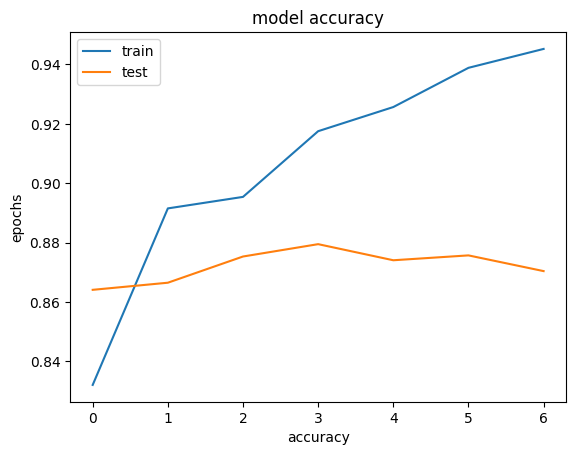

In [ ]:
#evaluate model
plt.figure()
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='test')
plt.title('model accuracy')
plt.ylabel('epochs')
plt.xlabel('accuracy')
plt.legend()
plt.show()

In [ ]:
loss,accuracy=model.evaluate(X_test,Y_test)
print(f"Test Loss:{loss}")
print(f"Test accuracy:{accuracy}")


310/310 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.8718 - loss: 0.3583
Test Loss:0.364230751991272
Test accuracy:0.871432900428772


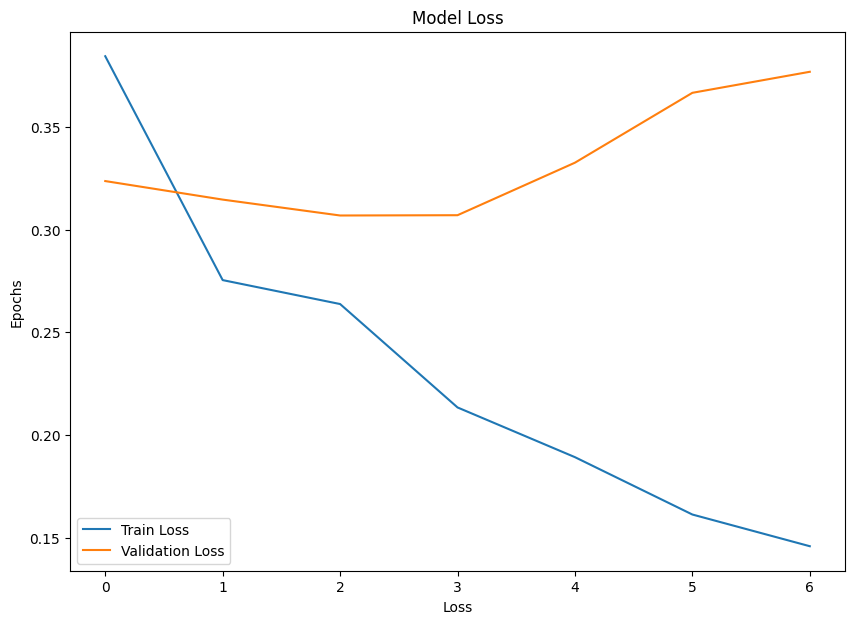

In [ ]:
# Plot Loss Graph
plt.figure(figsize=(10,7))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Loss')
plt.ylabel('Epochs')
plt.legend(['Train Loss','Validation Loss'])

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

In [ ]:
# Predict probabilities
y_pred = model.predict(X_test)

# Convert probabilities into classes (0 or 1)
y_pred_classes = (y_pred > 0.5).astype(int)

310/310 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step


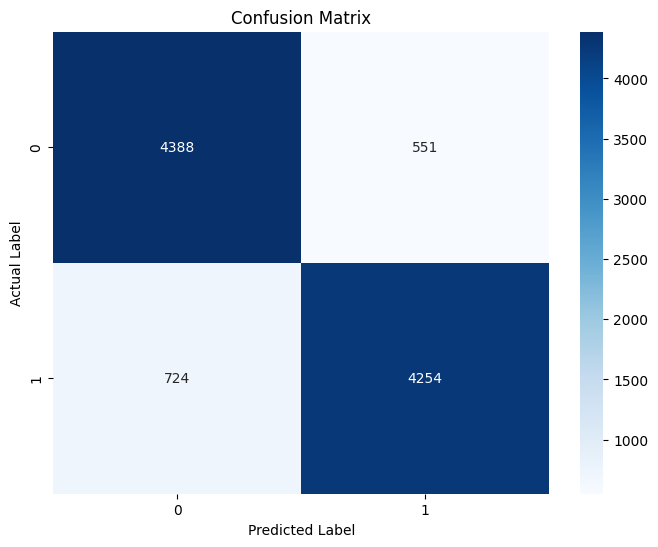

In [ ]:
cm = confusion_matrix(Y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [ ]:
print("Classification Report:\n")

print(classification_report(Y_test, y_pred_classes))

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      4939
           1       0.89      0.85      0.87      4978

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



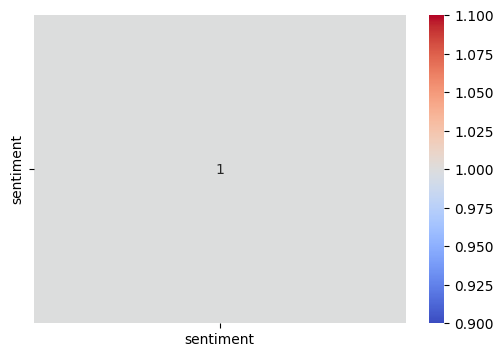

In [ ]:
# Correlation Matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
corr = data.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
#logistic regression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
a=data['review']
b=data['sentiment']

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(a,b,test_size=0.2,random_state=42)

In [ ]:
tfidf=TfidfVectorizer(max_features=5000,stop_words='english')
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

In [ ]:
log_reg=LogisticRegression(max_iter=5000)
log_reg.fit(X_train_tfidf,Y_train)

LogisticRegression(max_iter=5000)

In [ ]:
y_pred=log_reg.predict(X_test_tfidf)


In [ ]:
accuracy=accuracy_score(Y_test,y_pred)
print(accuracy)

0.8828274679842695


In [ ]:
#save model
import pickle

In [ ]:
pickle.dump(tokenizer,open('tokenizer.pkl','wb'))
pickle.dump(model,open('model.pkl','wb'))